# Regime Analysis — Extended

Extends Jimmy's exploratory work in `trend_vs_60_40_regime_analysis.ipynb` by loading his pre-computed outputs and adding:

1. **Regime Landscape** — frequency, episode duration, transition probabilities
2. **Enhanced Strategy Comparison** — Sharpe scatter, Information Ratio, correlation
3. **Drawdown Profile by Regime** — average underwater level per regime
4. **Dynamic MV Validation** — does the optimizer learn which regimes suit Trend?

In [12]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display

sys.path.insert(0, str(Path.cwd()))
from trend_analysis.metrics import drawdown, TRADING_DAYS
from trend_analysis.plots import apply_theme
apply_theme()

REGIME_DIR = Path('output/regime')
DATA_DIR   = Path('../data')

REGIME_ORDER = [
    'Bull Steepener', 'Bull Flattener', 'Bear Steepener',
    'Bear Flattener', 'Steepener Twist', 'Flattener Twist', 'Unclassified'
]
NAMED_REGIMES = [r for r in REGIME_ORDER if r != 'Unclassified']
REGIME_COLORS = {
    'Bull Steepener':  '#2E75B6',
    'Bull Flattener':  '#70AD47',
    'Bear Steepener':  '#C00000',
    'Bear Flattener':  '#FF7F0E',
    'Steepener Twist': '#7030A0',
    'Flattener Twist': '#00B0F0',
    'Unclassified':    '#BFBFBF',
}

In [13]:
# Load Jimmy's pre-computed regime outputs (don't recompute)
q1     = pd.read_csv(REGIME_DIR / 'q1_trend_by_regime.csv')
q2     = pd.read_csv(REGIME_DIR / 'q2_trend_vs_6040_by_regime.csv')
q3_avg = pd.read_csv(REGIME_DIR / 'q3_avg_weights_by_regime.csv')
q3_dyn = pd.read_csv(REGIME_DIR / 'q3_dynamic_weights_3asset.csv',
                     parse_dates=['date']).set_index('date')

# Raw daily regime labels (for duration / transition analysis)
regimes_raw = (pd.read_excel(DATA_DIR / 'interest_rate_regimes.xlsx',
                             parse_dates=['date'])
               .set_index('date')['regime_filtered'])

# Daily strategy returns
daily = pd.read_csv('output/merged_method1_vs_60_40_daily.csv',
                    parse_dates=['Dates'], index_col='Dates')

print(f'Regime data:  {regimes_raw.index.min().date()} to {regimes_raw.index.max().date()}')
print(f'Daily returns: {daily.index.min().date()} to {daily.index.max().date()}')
print(f'Unique regime labels: {sorted(regimes_raw.unique())}')

Regime data:  1990-10-17 to 2026-05-19
Daily returns: 2002-01-01 to 2026-04-20
Unique regime labels: ['Bear Flattener', 'Bear Steepener', 'Bull Flattener', 'Bull Steepener', 'Flattener Twist', 'Steepener Twist', 'Unclassified']


## Section 1 — Regime Landscape

How often does each regime occur and how long do episodes last?

In [14]:
def get_episodes(series):
    """Extract contiguous regime episodes from a daily series."""
    eps, prev, start = [], None, None
    for date, r in series.items():
        if r != prev:
            if prev is not None:
                eps.append({'regime': prev, 'start': start, 'end': date,
                            'days': (date - start).days})
            prev, start = r, date
    if prev is not None:
        eps.append({'regime': prev, 'start': start, 'end': series.index[-1],
                    'days': (series.index[-1] - start).days})
    return pd.DataFrame(eps)

ep_df = get_episodes(regimes_raw)

duration = (ep_df.groupby('regime')['days']
              .agg(Episodes='count', Total_Days='sum',
                   Avg_Days='mean', Median_Days='median')
              .round(1))
duration = duration.reindex([r for r in REGIME_ORDER if r in duration.index])
duration.to_csv(REGIME_DIR / 'regime_duration.csv')

display(duration.style
        .format({'Avg_Days': '{:.1f}', 'Median_Days': '{:.1f}'})
        .set_caption('Regime Duration Statistics (calendar days, 1990–2026)'))

,Episodes,Total_Days,Avg_Days,Median_Days
regime,,,,
Bull Steepener,21,2270,108.1,90.0
Bull Flattener,21,1500,71.4,46.0
Bear Steepener,20,760,38.0,24.5
Bear Flattener,16,1849,115.6,56.0
Steepener Twist,9,150,16.7,17.0
Flattener Twist,11,379,34.5,32.0
Unclassified,96,6090,63.4,35.0


- Bull Steepener is the longest-lasting regime (avg 108 days/episode) and along with Bear Flattener (avg 116 days) these are the two "sticky" regimes — when you enter them you stay a while

- Steepener Twist is the shortest and rarest (avg 17 days, only 9 episodes since 1990) — it's a fleeting transitional state

- Unclassified has 96 episodes averaging 63 days — this is the persistence filter doing its job, holding off a label until the signal is confirmed for 5 straight days

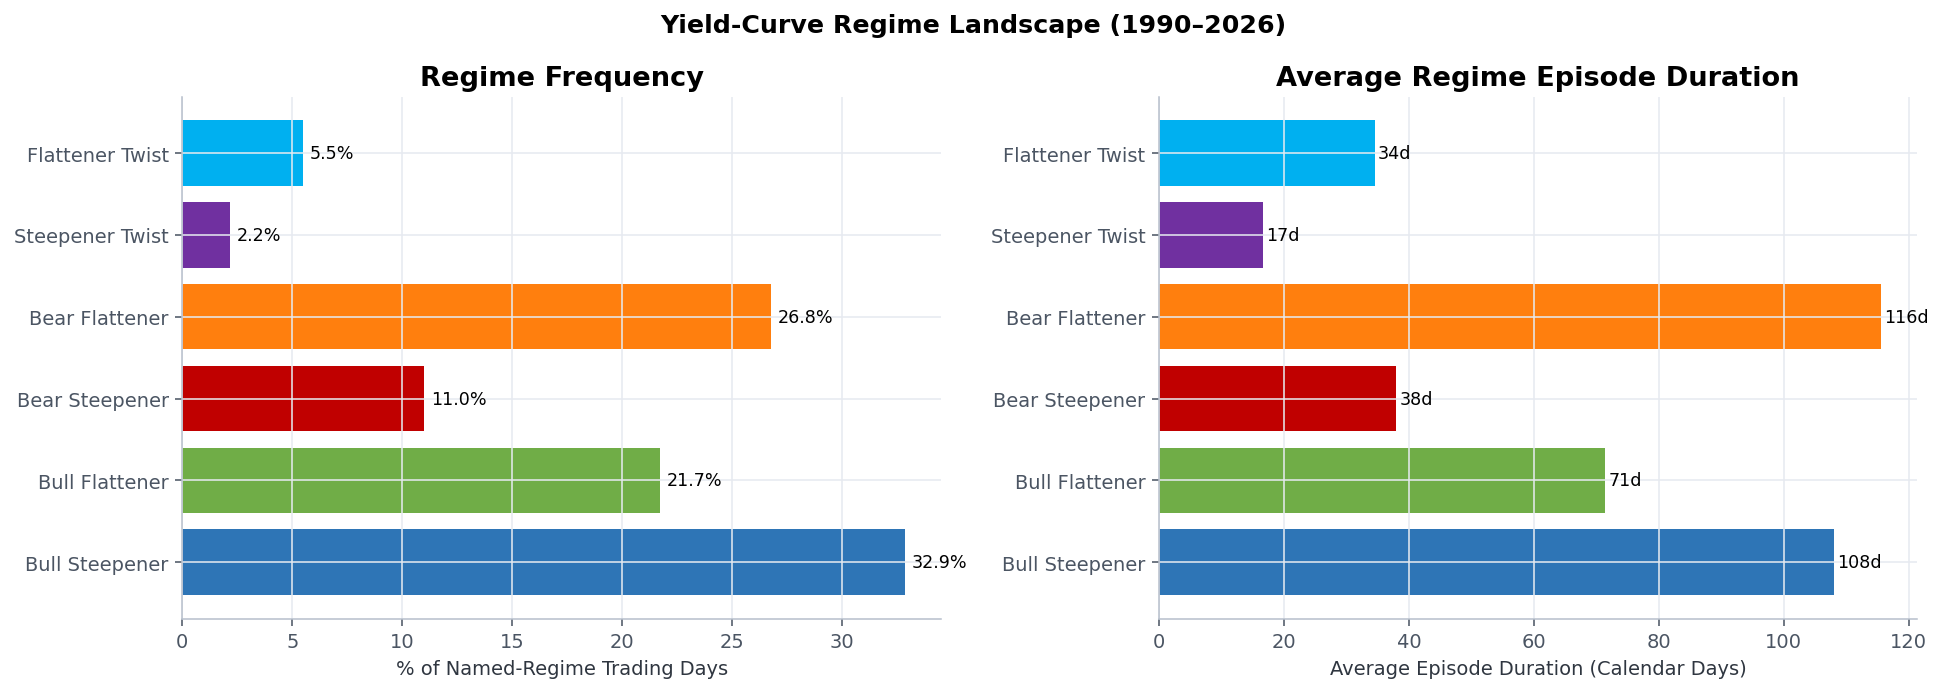

In [16]:
named_dur = duration.drop('Unclassified', errors='ignore').reindex(
    [r for r in NAMED_REGIMES if r in duration.index]).dropna()
pct_days  = named_dur['Total_Days'] / named_dur['Total_Days'].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = [REGIME_COLORS[r] for r in pct_days.index]
axes[0].barh(pct_days.index, pct_days.values, color=colors)
axes[0].set_xlabel('% of Named-Regime Trading Days')
axes[0].set_title('Regime Frequency')
for i, v in enumerate(pct_days.values):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

avg_dur = named_dur['Avg_Days']
axes[1].barh(avg_dur.index, avg_dur.values,
             color=[REGIME_COLORS[r] for r in avg_dur.index])
axes[1].set_xlabel('Average Episode Duration (Calendar Days)')
axes[1].set_title('Average Regime Episode Duration')
for i, v in enumerate(avg_dur.values):
    axes[1].text(v + 0.5, i, f'{v:.0f}d', va='center', fontsize=9)

plt.suptitle('Yield-Curve Regime Landscape (1990–2026)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REGIME_DIR / 'regime_landscape.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 2 — Enhanced Strategy Comparison by Regime

- **Sharpe scatter**: which regimes favor Trend vs 60/40?
- **Information Ratio**: how consistently does Trend beat 60/40 within each regime?
- **Correlation**: in which regimes does Trend diversify most?

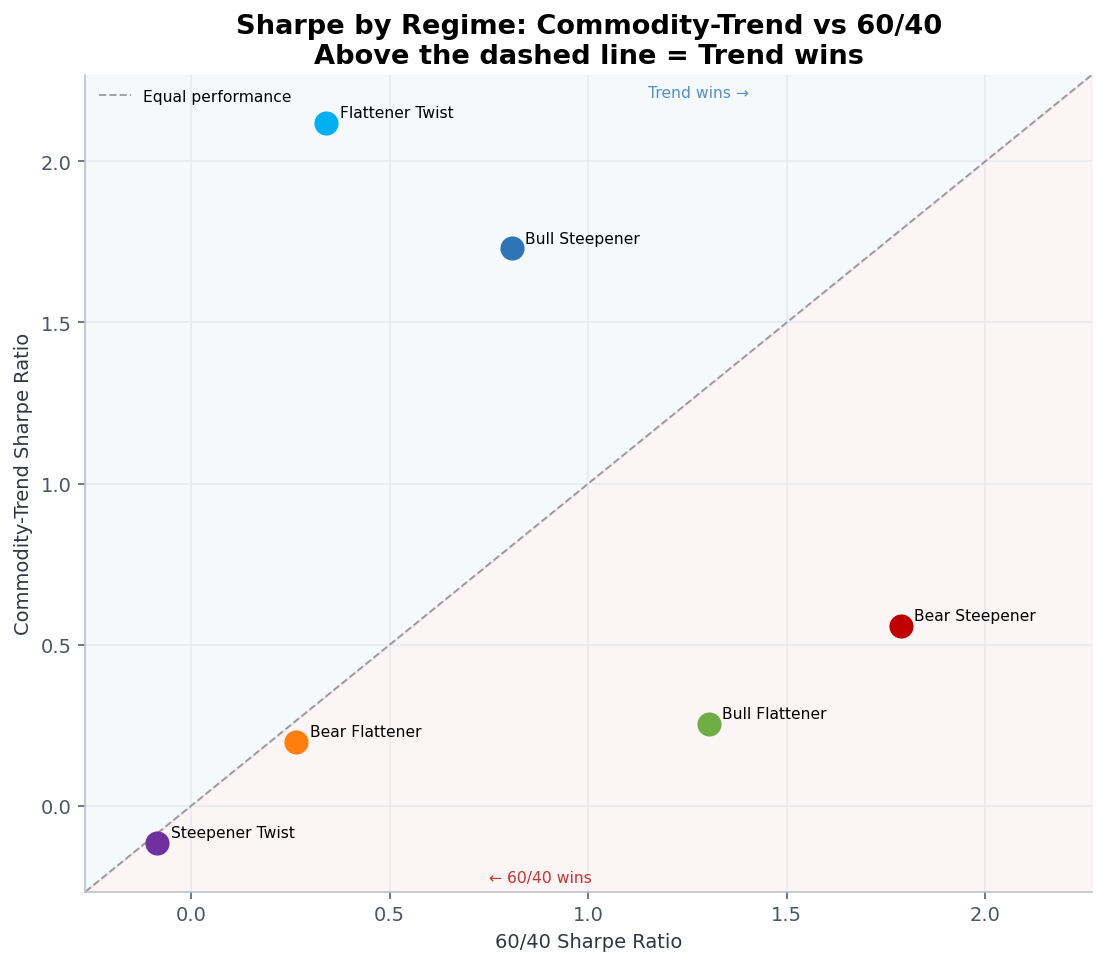

In [17]:
q2_named = q2[q2['Regime'] != 'Unclassified'].set_index('Regime')
lo = min(q2_named['Commodity-Trend Sharpe'].min(), q2_named['60/40 Sharpe'].min()) - 0.15
hi = max(q2_named['Commodity-Trend Sharpe'].max(), q2_named['60/40 Sharpe'].max()) + 0.15

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.35, lw=1, label='Equal performance')
ax.fill_between([lo, hi], [lo, hi], hi, alpha=0.04, color='#2E75B6')
ax.fill_between([lo, hi], lo, [lo, hi], alpha=0.04, color='#C00000')
ax.text((lo+hi)/2 + 0.15, hi - 0.07, 'Trend wins →', fontsize=8, color='#2E75B6', alpha=0.8)
ax.text((lo+hi)/2 - 0.25, lo + 0.03, '← 60/40 wins', fontsize=8, color='#C00000', alpha=0.8)

for regime, row in q2_named.iterrows():
    ax.scatter(row['60/40 Sharpe'], row['Commodity-Trend Sharpe'],
               color=REGIME_COLORS.get(regime, '#999'), s=130, zorder=3)
    ax.annotate(regime, (row['60/40 Sharpe'], row['Commodity-Trend Sharpe']),
                textcoords='offset points', xytext=(7, 3), fontsize=8)

ax.set_xlabel('60/40 Sharpe Ratio')
ax.set_ylabel('Commodity-Trend Sharpe Ratio')
ax.set_title('Sharpe by Regime: Commodity-Trend vs 60/40\nAbove the dashed line = Trend wins')
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(REGIME_DIR / 'regime_sharpe_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

- Only two regimes favor Trend: Bull Steepener (Trend 1.73 vs 60/40 0.81) and Flattener Twist (Trend 2.12 vs 60/40 0.34). These are the regimes where rates are either falling or the curve is normalizing.

- All four other named regimes favor 60/40, sometimes decisively — Bear Steepener is the worst for Trend (Trend 0.56 vs 60/40 1.79)

Need to define economic reasoning for why this potentially occurred

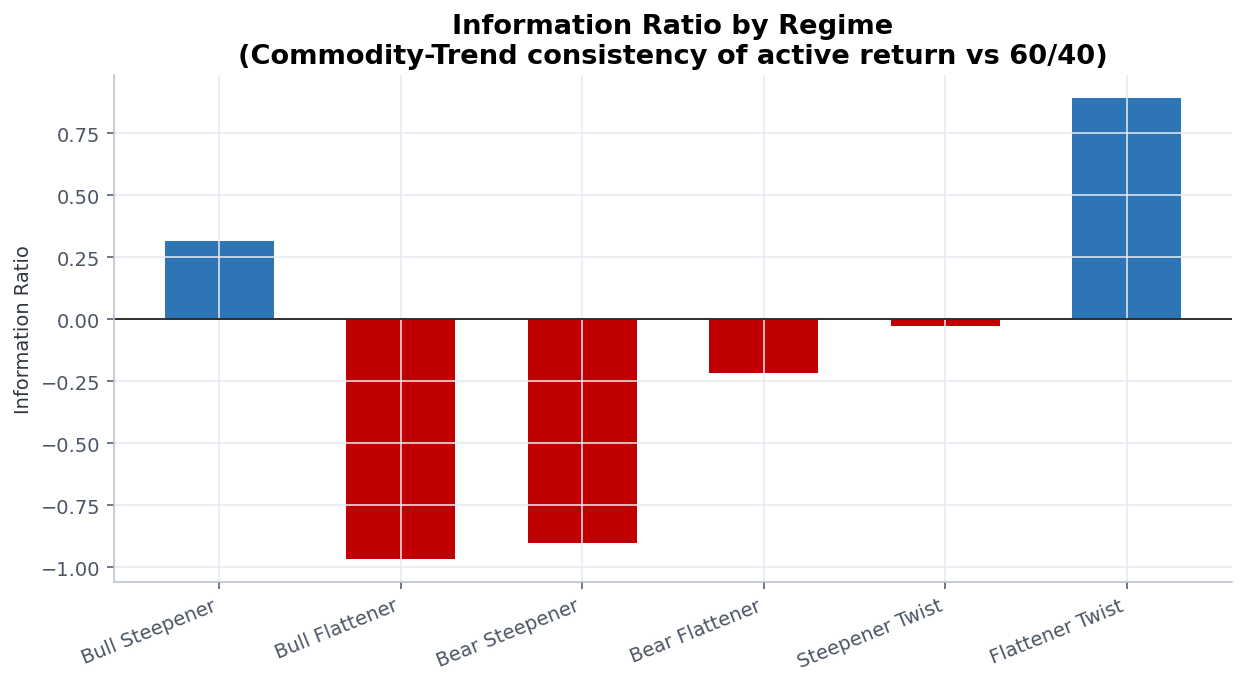

,Ann. Active Return,Tracking Error (Ann.),Information Ratio
Regime,,,
Bull Steepener,0.051,0.163,0.316
Bull Flattener,-0.119,0.123,-0.965
Bear Steepener,-0.088,0.098,-0.901
Bear Flattener,-0.025,0.116,-0.215
Steepener Twist,-0.003,0.099,-0.026
Flattener Twist,0.079,0.088,0.893
Unclassified,-0.041,0.114,-0.355


In [7]:
# Information Ratio = annualised active return / annualised tracking error
joint = daily[['method1_strategy_return', 'benchmark_strategy_return']].join(
    regimes_raw.rename('regime'), how='inner')
joint['active'] = joint['method1_strategy_return'] - joint['benchmark_strategy_return']

ir_rows = []
for regime in REGIME_ORDER:
    sub = joint.loc[joint['regime'] == regime, 'active'].dropna()
    if len(sub) < 30:
        continue
    ann_active = sub.mean() * TRADING_DAYS
    te         = sub.std() * np.sqrt(TRADING_DAYS)
    ir         = ann_active / te if te > 0 else np.nan
    ir_rows.append({'Regime': regime, 'Ann. Active Return': ann_active,
                    'Tracking Error (Ann.)': te, 'Information Ratio': ir})

ir_df = pd.DataFrame(ir_rows).set_index('Regime')
ir_df.to_csv(REGIME_DIR / 'regime_ir.csv')

named_ir   = ir_df.drop('Unclassified', errors='ignore').reindex(
    [r for r in NAMED_REGIMES if r in ir_df.index])
colors_ir  = ['#2E75B6' if v >= 0 else '#C00000'
              for v in named_ir['Information Ratio']]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(named_ir.index, named_ir['Information Ratio'], color=colors_ir, width=0.6)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Information Ratio')
ax.set_title('Information Ratio by Regime\n'
             '(Commodity-Trend consistency of active return vs 60/40)')
plt.xticks(rotation=22, ha='right')
plt.tight_layout()
plt.savefig(REGIME_DIR / 'regime_information_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

display(ir_df.style.format('{:.3f}').set_caption('Information Ratio by Regime'))

Reinforces results above.

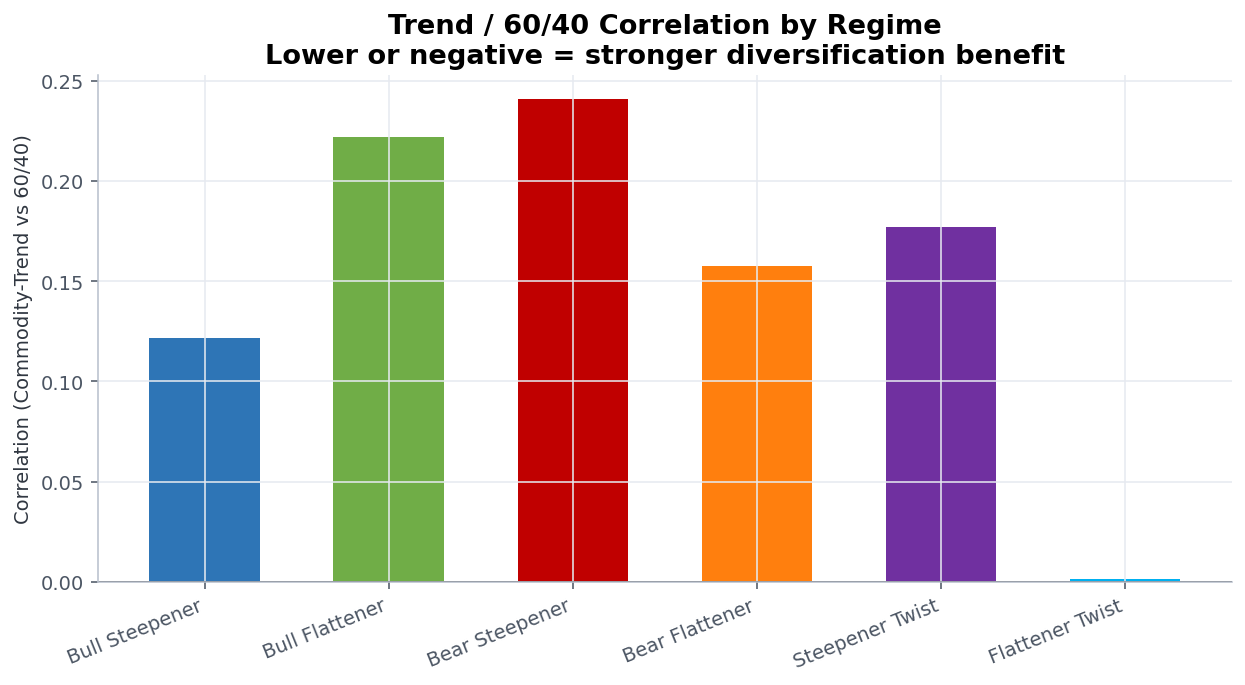

In [18]:
corr_s = q2_named['Corr'].reindex([r for r in NAMED_REGIMES if r in q2_named.index])

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(corr_s.index, corr_s.values,
       color=[REGIME_COLORS.get(r, '#999') for r in corr_s.index], width=0.6)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Correlation (Commodity-Trend vs 60/40)')
ax.set_title('Trend / 60/40 Correlation by Regime\n'
             'Lower or negative = stronger diversification benefit')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
plt.xticks(rotation=22, ha='right')
plt.tight_layout()
plt.savefig(REGIME_DIR / 'regime_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

Trend decorrelates most in Flattener Twist (correlation near zero) and Bull Steepener (0.12) which aligns with the fact that these are the two regimes where it also outperforms. This makes sense as the diversification benefits seem to line up with performance benefit.

## Section 3 — Drawdown Profile by Regime

Average daily underwater level (drawdown from all-time high) for each strategy while in each yield-curve regime. Shows which regimes are persistently painful.

In [19]:
joint_full = daily[['method1_strategy_return', 'benchmark_strategy_return']].join(
    regimes_raw.rename('regime'), how='inner'
).join(q3_dyn[['ret_dynamic_mv_3a']], how='left')

# Compute drawdown series on the full period, then average within regime
trend_dd = drawdown(joint_full['method1_strategy_return'])
bench_dd = drawdown(joint_full['benchmark_strategy_return'])
dyn_dd   = drawdown(joint_full['ret_dynamic_mv_3a'].dropna())

joint_full['trend_dd'] = trend_dd
joint_full['bench_dd'] = bench_dd
joint_full = joint_full.join(dyn_dd.rename('dyn_dd'), how='left')

dd_profile = (joint_full.groupby('regime')[['trend_dd', 'bench_dd', 'dyn_dd']]
                .mean()
                .reindex([r for r in REGIME_ORDER if r in joint_full['regime'].unique()]))
dd_profile.columns = ['Commodity-Trend', '60/40', 'Dynamic MV']
dd_profile.to_csv(REGIME_DIR / 'regime_dd_profile.csv')

display(dd_profile.style.format('{:.2%}')
        .set_caption('Average Daily Underwater Level by Regime'))

,Commodity-Trend,60/40,Dynamic MV
regime,,,
Bull Steepener,-5.26%,-7.10%,-3.45%
Bull Flattener,-5.42%,-5.19%,-1.38%
Bear Steepener,-5.04%,-2.80%,-4.09%
Bear Flattener,-5.26%,-5.72%,-4.99%
Steepener Twist,-5.95%,-7.57%,-4.07%
Flattener Twist,-5.29%,-0.95%,-0.45%
Unclassified,-6.40%,-2.74%,-2.33%


- In Bull Steepener the 60/40 is more underwater on average than Trend. Trend is actively providing relief during the regime where equities/bonds do well but experience volatility

- In Flattener Twist the 60/40 is barely underwater because it's rallying, while Trend is at -5.3%. However, Trend is still generating a Sharpe of 2.1, so those drawdowns recover fast

- Dynamic MV is consistently shallower than both strategies in most regimes which means the optimizer is doing its job of smoothing the ride

- Bear Steepener is the outlier: Trend is more underwater than 60/40 (-5.0% vs -2.8%), which is consistent with its poor Sharpe in that regime

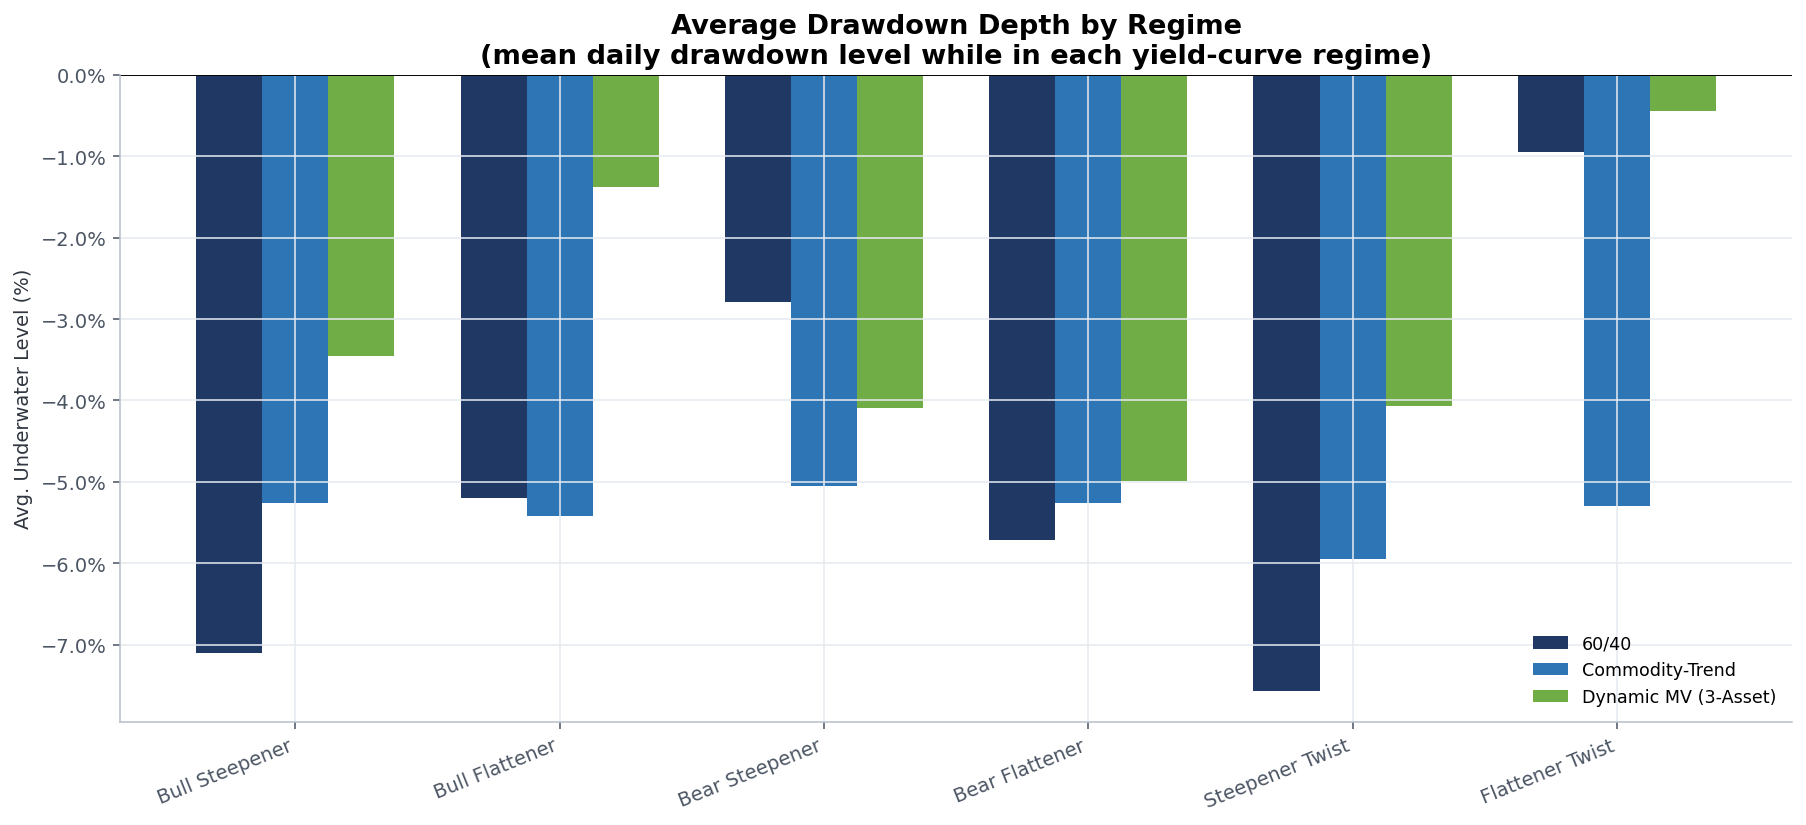

In [20]:
named_dd = dd_profile.drop('Unclassified', errors='ignore').reindex(
    [r for r in NAMED_REGIMES if r in dd_profile.index]).dropna()

x, width = np.arange(len(named_dd)), 0.25
fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - width, named_dd['60/40'] * 100,           width, label='60/40',              color='#1F3864')
ax.bar(x,         named_dd['Commodity-Trend'] * 100, width, label='Commodity-Trend',    color='#2E75B6')
ax.bar(x + width, named_dd['Dynamic MV'] * 100,      width, label='Dynamic MV (3-Asset)', color='#70AD47')
ax.set_xticks(x)
ax.set_xticklabels(named_dd.index, rotation=22, ha='right')
ax.set_ylabel('Avg. Underwater Level (%)')
ax.set_title('Average Drawdown Depth by Regime\n'
             '(mean daily drawdown level while in each yield-curve regime)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.axhline(0, color='black', lw=0.5)
ax.legend()
plt.tight_layout()
plt.savefig(REGIME_DIR / 'regime_dd_profile.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 4 — Does the Dynamic MV Learn Which Regimes Suit Trend?

If the rolling mean-variance optimizer is capturing regime-conditional information, its average Trend allocation should be higher in regimes where Trend has a high Sharpe — and lower in regimes where it underperforms.

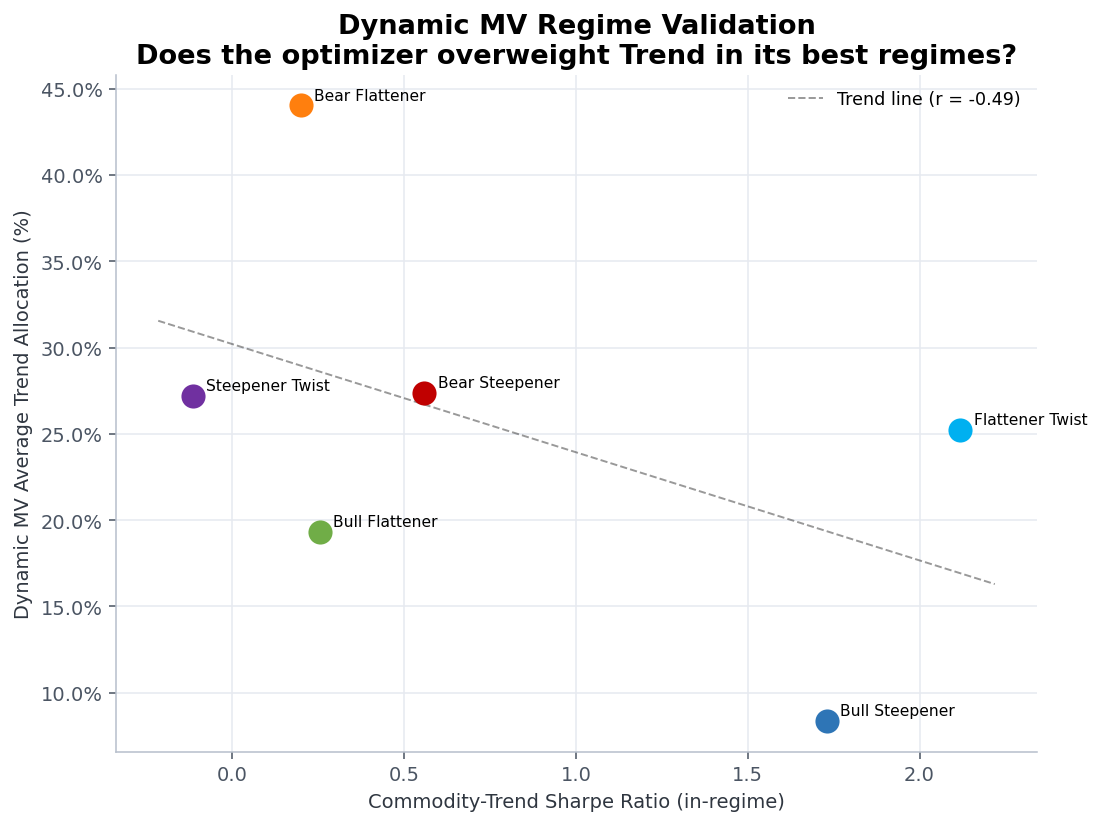

,Sharpe,Avg Trend weight %
Regime,,
Bull Steepener,1.73,8.4%
Bull Flattener,0.25,19.3%
Bear Steepener,0.56,27.4%
Bear Flattener,0.20,44.0%
Steepener Twist,-0.12,27.2%
Flattener Twist,2.12,25.2%


In [21]:
q1_named = q1[q1['Regime'] != 'Unclassified'].set_index('Regime')
q3_named = q3_avg[q3_avg['Regime'] != 'Unclassified'].set_index('Regime')

merged_val = q1_named[['Sharpe']].join(q3_named[['Avg Trend weight']], how='inner')
merged_val['Avg Trend weight %'] = merged_val['Avg Trend weight'] * 100
merged_val.to_csv(REGIME_DIR / 'mv_regime_validation.csv')

x_v = merged_val['Sharpe'].values
y_v = merged_val['Avg Trend weight %'].values
corr_r = np.corrcoef(x_v, y_v)[0, 1] if len(x_v) >= 2 else np.nan

fig, ax = plt.subplots(figsize=(8, 6))
for regime, row in merged_val.iterrows():
    ax.scatter(row['Sharpe'], row['Avg Trend weight %'],
               color=REGIME_COLORS.get(regime, '#999'), s=130, zorder=3)
    ax.annotate(regime, (row['Sharpe'], row['Avg Trend weight %']),
                textcoords='offset points', xytext=(7, 3), fontsize=8)

if len(x_v) >= 2:
    m, b = np.polyfit(x_v, y_v, 1)
    xl = np.linspace(x_v.min() - 0.1, x_v.max() + 0.1, 50)
    ax.plot(xl, m * xl + b, 'k--', alpha=0.4, lw=1, label=f'Trend line (r = {corr_r:.2f})')
    ax.legend(fontsize=9)

ax.set_xlabel('Commodity-Trend Sharpe Ratio (in-regime)')
ax.set_ylabel('Dynamic MV Average Trend Allocation (%)')
ax.set_title('Dynamic MV Regime Validation\n'
             'Does the optimizer overweight Trend in its best regimes?')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.savefig(REGIME_DIR / 'mv_regime_validation.png', dpi=150, bbox_inches='tight')
plt.show()

display(merged_val[['Sharpe', 'Avg Trend weight %']]
        .style.format({'Sharpe': '{:.2f}', 'Avg Trend weight %': '{:.1f}%'})
        .set_caption('Trend Sharpe vs Dynamic MV Avg Trend Allocation by Regime'))

The scatter shows a negative correlation between Trend's Sharpe and the MV optimizer's average Trend weight. The optimizer gives Trend its lowest weight in Bull Steepener (8.4%), Trend's best regime and its highest weight in Bear Flattener (44%), one of Trend's worst regimes by Sharpe.

This is counterintuitive but could make sense as the MV optimizer doesn't care about Trend's standalone Sharpe. It cares about how Trend interacts with stocks and bonds. In Bear Flattener, Trend has low correlation to the other two assets (rates falling, commodities/FX moving differently), so it provides maximum diversification benefit even if its own return is low. In Bull Steepener, everything does well together and Trend is just another correlated asset so the optimizer doesn't need it much. The MV optimzer rewards diversification, not just performance.